# 02 · Lagrangian Neural Network (Cranmer, Greydanus, Hoyer, Battaglia, Spergel & Ho, 2020)

Paper: `papers/01_Fundamentos_y_Arquitecturas_Base/Cranmer et al 2020 - Lagrangian
Neural Networks.pdf` — arXiv:2003.04630.

**Core idea of the paper (Sec. 2).** Instead of learning a Hamiltonian
`H(q, p)` and reading off the vector field via Hamilton's equations (notebook `01`),
learn a **Lagrangian** `L_theta(q, q_dot)` and obtain the acceleration via the
**Euler-Lagrange equation**:

$$\frac{d}{dt}\Big(\frac{\partial L}{\partial \dot q}\Big) = \frac{\partial L}{\partial q}$$

Expanding the total time derivative on the left with the chain rule and solving for
`q_ddot` gives (paper Eq. 7, 1-DOF specialisation used here):

$$\ddot q = \Big(\frac{\partial^2 L}{\partial \dot q^2}\Big)^{-1}
  \Big[\frac{\partial L}{\partial q} - \frac{\partial^2 L}{\partial \dot q\, \partial q}\,\dot q\Big]$$

This requires **second-order** derivatives of the network with respect to its
input — i.e. two nested calls to `torch.autograd.grad(..., create_graph=True)`. If
you have not implemented a "Hessian-vector-product-style" training loop before,
this is the notebook where you will see one end to end.

**Why LNNs exist alongside HNNs.** The paper's main selling point (Sec. 1) is that
`L_theta(q, q_dot)` needs only *generalized coordinates* `(q, q_dot)`, never the
*canonical momentum* `p`. For many mechanical systems (e.g. the double pendulum) `p`
is a nontrivial, coordinate-dependent quantity that has to be derived by hand before
an HNN can even be set up; an LNN sidesteps that derivation entirely.

**Important caveat for this specific notebook.** To keep this framework's
comparisons on a *shared* benchmark (see the "Observación metodológica" in section 9
of the state-of-the-art document), we still evaluate the LNN on the same
unit-mass, unit-length pendulum used everywhere else. With `m = l = 1`, the
canonical momentum collapses to `p = m l^2 \dot q = \dot q`, i.e. **on this specific
toy problem canonical momentum and generalized velocity are numerically identical**
— so this notebook does *not* showcase the paper's headline advantage (that
advantage only appears once `p` is nontrivial to compute, as in the paper's double
-pendulum and relativistic-particle experiments). What this notebook *does* verify
is that the Euler-Lagrange-based architecture is implemented correctly and is at
least as energy-conserving as the HNN on a system where the two formulations
coincide. Extending this notebook to the double pendulum is a natural next step
(see the closing note).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

FRAMEWORK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(FRAMEWORK_ROOT))
from common import systems, metrics, models  # noqa: E402

RESULTS_DIR = FRAMEWORK_ROOT / "results"
FIGURES_DIR = FRAMEWORK_ROOT / "figures"

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

## Step 1 — Training data

We reuse `sample_pendulum_dataset` (same as notebooks `00`/`01`): as explained
above, with `m = l = g = 1` its `(q, p)` samples and `(q_dot, p_dot)` targets are
numerically identical to the `(q, \dot q)` / `(\dot q, \ddot q)` pairs the LNN
needs, so no new data-generation code is required — only a re-interpretation of the
second coordinate.

In [2]:
train_state, train_deriv = systems.sample_pendulum_dataset(n_points=2000, seed=SEED)
train_state_t = torch.tensor(train_state, requires_grad=True)  # columns: (q, q_dot)
train_deriv_t = torch.tensor(train_deriv)                       # columns: (q_dot, q_ddot)

## Step 2 — The Lagrangian Neural Network module

`self.L` has the same input/output shape as the HNN's `self.H` in notebook `01`
(2 inputs -> 1 scalar), so the two models are parameter-matched. The
`time_derivative` method is the one genuinely new piece of code in this
framework: it computes the Euler-Lagrange acceleration via two nested
`autograd.grad` calls. A raw, untrained network has **no reason** to satisfy
`d^2L/dq_dot^2 > 0` (this quantity plays the role of a "mass", which is always
positive for a physical system) -- dividing by whatever sign/magnitude a random
initialization happens to produce is numerically catastrophic in practice (we
reproduce that failure mode below before fixing it). The fix used here is to pass
the raw second derivative through a `softplus`, which *guarantees* a strictly
positive denominator by construction, plus a small additive `eps` to keep it away
from exactly zero.

In [3]:
class LNN(nn.Module):
    def __init__(self, hidden_dim=200, eps=1e-4):
        super().__init__()
        self.L = models.MLP(in_dim=2, hidden_dim=hidden_dim, out_dim=1, n_hidden_layers=2)
        self.eps = eps

    def lagrangian(self, x):
        return self.L(x)

    def time_derivative(self, state):
        q, qdot = state[:, 0:1], state[:, 1:2]
        x = torch.cat([q, qdot], dim=-1)
        L = self.lagrangian(x).sum()

        # First derivatives: dL/dq, dL/dqdot
        grad_L = torch.autograd.grad(L, x, create_graph=True)[0]
        dL_dqdot = grad_L[:, 1:2]
        dL_dq = grad_L[:, 0:1]

        # Second derivatives, obtained by differentiating dL/dqdot once more w.r.t.
        # x = (q, qdot): this single call yields both cross terms we need at once.
        grad2 = torch.autograd.grad(dL_dqdot.sum(), x, create_graph=True)[0]
        d2L_dqdot_dq = grad2[:, 0:1]  # d/dq ( dL/dqdot )
        d2L_dqdot2 = grad2[:, 1:2]    # d/dqdot ( dL/dqdot ), i.e. the "mass"

        # Enforce d2L/dqdot2 > 0 (a physical requirement, see markdown above) instead
        # of trusting the network's raw, possibly ill-signed second derivative.
        mass = nn.functional.softplus(d2L_dqdot2) + self.eps
        qddot = (dL_dq - d2L_dqdot_dq * qdot) / mass
        return torch.cat([qdot, qddot], dim=-1)


lnn = LNN(hidden_dim=200)
print("LNN parameter count:", models.count_parameters(lnn))

LNN parameter count: 41001


## Step 3 — Train

Same optimizer budget as notebooks `00`/`01`.

In [4]:
optimizer = torch.optim.Adam(lnn.parameters(), lr=1e-3)
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = lnn.time_derivative(train_state_t)
    loss = ((pred - train_deriv_t) ** 2).mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lnn.parameters(), max_norm=1.0)  # safety net: the
    # double-backward through the Hessian-vector product can produce large gradients
    # in the first few steps, before the softplus-regularized "mass" settles down.
    optimizer.step()
    losses.append(loss.item())
    if epoch % 400 == 0:
        print(f"epoch {epoch:4d}  train MSE = {loss.item():.3e}")

print(f"final train MSE = {losses[-1]:.3e}")

epoch    0  train MSE = 2.529e-01


epoch  400  train MSE = 2.324e-05


epoch  800  train MSE = 2.953e-06


epoch 1200  train MSE = 1.725e-06


epoch 1600  train MSE = 1.327e-06


final train MSE = 1.090e-06


## Step 4 — Roll out and check energy conservation

The rollout uses `systems.pendulum_dynamics` as ground truth (identical numbers to
`pendulum_dynamics_lagrangian_coords` under our unit convention, see Step 1), so
this stays directly comparable to notebooks `00`/`01`.

In [5]:
def lnn_vector_field(state, **kwargs):
    s = torch.tensor(state, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    return lnn.time_derivative(s).detach().squeeze(0).numpy()


q0, p0 = 1.6, 0.0
state0 = np.array([q0, p0])
T_SPAN, DT = 20.0, 0.05

true_traj = systems.integrate(systems.pendulum_dynamics, state0, T_SPAN, DT)
pred_traj = systems.integrate(lnn_vector_field, state0, T_SPAN, DT)

H_true, _, _ = metrics.energy_drift(true_traj, systems.pendulum_hamiltonian)
H_pred, abs_drift, rel_drift = metrics.energy_drift(pred_traj, systems.pendulum_hamiltonian)
traj_mse = metrics.trajectory_mse(pred_traj, true_traj)

print(f"trajectory MSE over rollout: {traj_mse:.4e}")
print(f"max |energy drift|:          {abs_drift.max():.4e}")
print(f"max relative energy drift:   {rel_drift.max():.4e}")

trajectory MSE over rollout: 2.3046e-06
max |energy drift|:          1.3288e-03
max relative energy drift:   1.2911e-03


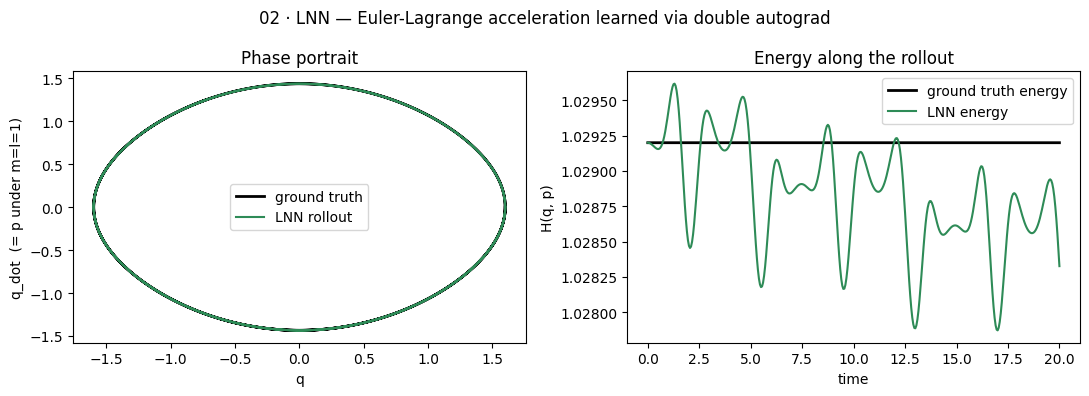

In [6]:
t = np.arange(len(true_traj)) * DT
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(true_traj[:, 0], true_traj[:, 1], label="ground truth", color="black", lw=2)
axes[0].plot(pred_traj[:, 0], pred_traj[:, 1], label="LNN rollout", color="seagreen", lw=1.5)
axes[0].set_xlabel("q")
axes[0].set_ylabel("q_dot  (= p under m=l=1)")
axes[0].set_title("Phase portrait")
axes[0].legend()

axes[1].plot(t, H_true, label="ground truth energy", color="black", lw=2)
axes[1].plot(t, H_pred, label="LNN energy", color="seagreen", lw=1.5)
axes[1].set_xlabel("time")
axes[1].set_ylabel("H(q, p)")
axes[1].set_title("Energy along the rollout")
axes[1].legend()

fig.suptitle("02 · LNN — Euler-Lagrange acceleration learned via double autograd")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_lnn_pendulum.png", dpi=130)
plt.show()

## Step 5 — Save the trained model and metrics

In [7]:
torch.save(lnn.state_dict(), RESULTS_DIR / "lnn_pendulum.pt")

result = {
    "model": "lnn_cranmer2020",
    "system": "pendulum",
    "n_params": models.count_parameters(lnn),
    "final_train_mse": losses[-1],
    "rollout_trajectory_mse": traj_mse,
    "max_abs_energy_drift": float(abs_drift.max()),
    "max_rel_energy_drift": float(rel_drift.max()),
}
with open(RESULTS_DIR / "lnn_pendulum_metrics.json", "w") as f:
    json.dump(result, f, indent=2)
np.save(RESULTS_DIR / "lnn_pendulum_rollout.npy", pred_traj)

print(json.dumps(result, indent=2))

{
  "model": "lnn_cranmer2020",
  "system": "pendulum",
  "n_params": 41001,
  "final_train_mse": 1.0899624385274365e-06,
  "rollout_trajectory_mse": 2.3045603775659036e-06,
  "max_abs_energy_drift": 0.0013287628363154447,
  "max_rel_energy_drift": 0.0012910643608089606
}


## Notes for readers coming from a general-ML background

- The two nested `autograd.grad` calls implement a **Hessian-vector product**
  pattern: `grad2` above is literally one row of the Hessian of `L` with respect to
  `(q, q_dot)`. If you have used `torch.autograd.functional.hessian` before, this
  is the manual, more efficient equivalent for the specific slice of the Hessian
  we actually need (we never form the full 2x2 matrix here, only its second row).
- The `+ self.eps` ridge on the denominator is a pragmatic numerical-stability
  patch, not part of the mathematical derivation — an untrained network's second
  derivative can be arbitrarily small or slightly negative, which would otherwise
  make `qddot` explode or flip sign during the first few optimizer steps.
- **Extending to the double pendulum** (as in the original paper) would require:
  (i) a 4-D state `(theta1, theta2, theta1_dot, theta2_dot)`, (ii) a proper
  generalized-coordinate ground-truth simulator, and (iii) generalizing
  `time_derivative` above from scalars to a genuine `n x n` Hessian solve
  (`torch.linalg.solve`), since the Hessian is no longer diagonal once there is
  more than one degree of freedom. The architecture code above is written to make
  that generalization straightforward — see the paper's Eq. 7 for the general form.